<a href="https://colab.research.google.com/github/Mythili-kirupakaran/Data-visualization-/blob/main/DVT%20WEEK-3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving E Commerce.csv to E Commerce (2).csv
  order_id customer_id  age product_id   country signup_date  \
0  ORD5000    CUST1000   39    PROD200    Canada  01-07-2021   
1  ORD5001    CUST1001   61    PROD201       USA  10/19/2020   
2  ORD5002    CUST1002   26    PROD202  Pakistan  06-10-2023   
3  ORD5003    CUST1003   54    PROD203     India   7/30/2023   
4  ORD5004    CUST1004   50    PROD204     India  12-09-2020   

  last_purchase_date  cancellations_count subscription_status  order_date  \
0          2/21/2023                    0              active   8/20/2024   
1         12-08-2021                    0              active   7/17/2025   
2         09-04-2023                    3           cancelled  03-12-2025   
3          2/20/2024                    4              paused   9/19/2024   
4          9/14/2024                    0              active  08-08-2024   

   unit_price  quantity  purchase_frequency preferred_category  product_name  \
0       78.21         5     

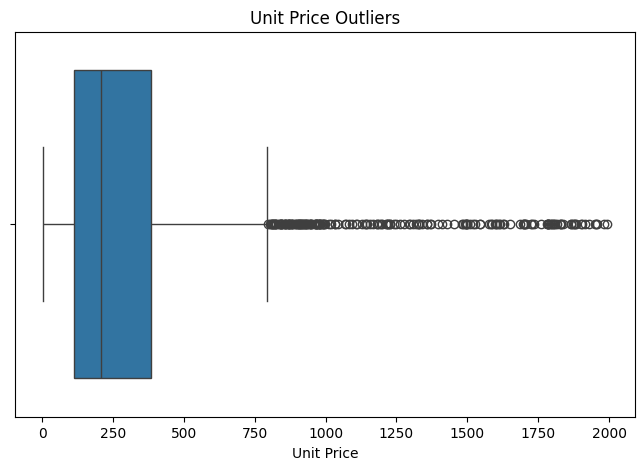


Scaled Unit Price
   unit_price
0    0.037893
1    0.030758
2    0.302341
3    0.041136
4    0.030074

Encoded Categorical Columns
   country  preferred_category  product_name  category  gender
0        0                   4            12         4       0
1        5                   4            26         3       0
2        3                   2            16         1       0
3        2                   4             5         0       1
4        2                   4            32         2       1

One-Hot Encoded Category
   Category_0  Category_1  Category_2  Category_3  Category_4
0       False       False       False       False        True
1       False       False       False        True       False
2       False        True       False       False       False
3        True       False       False       False       False
4       False       False        True       False       False

Cleaned dataset saved successfully.


In [3]:
# ==========================================
# DATA PREPROCESSING
# Retail & Supply Chain Analytics
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder

from google.colab import files


# ------------------------------------------
# Upload Dataset
# ------------------------------------------

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)


# ------------------------------------------
# Data Understanding
# ------------------------------------------

print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
df.info()


# ------------------------------------------
# Missing Values
# ------------------------------------------

print("\nMissing Values")
print(df.isnull().sum())


# Fill missing numerical values
numeric_cols = df.select_dtypes(
    include=np.number
).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

print("\nMissing Values After Filling")
print(df.isnull().sum())


# ------------------------------------------
# Duplicate Rows
# ------------------------------------------

print("\nDuplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("After Removal:", df.shape)


# ------------------------------------------
# Outlier Detection
# Using Unit Price
# ------------------------------------------

Q1 = df["unit_price"].quantile(0.25)
Q3 = df["unit_price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["unit_price"] < lower) |
    (df["unit_price"] > upper)
]

print("\nOutliers")
print(outliers.head())

print("Number of outliers:", len(outliers))


# ------------------------------------------
# Boxplot
# ------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(x=df["unit_price"])

plt.title("Unit Price Outliers")
plt.xlabel("Unit Price")

plt.show()


# ------------------------------------------
# Min-Max Scaling
# ------------------------------------------

scaler = MinMaxScaler()

df[["unit_price"]] = scaler.fit_transform(
    df[["unit_price"]]
)

print("\nScaled Unit Price")
print(df[["unit_price"]].head())


# ------------------------------------------
# Label Encoding
# ------------------------------------------

encoder = LabelEncoder()

categorical_columns = [
    "country",
    "preferred_category",
    "product_name",
    "category",
    "gender"
]

for col in categorical_columns:

    df[col] = encoder.fit_transform(
        df[col].astype(str)
    )

print("\nEncoded Categorical Columns")

print(
    df[categorical_columns].head()
)


# ------------------------------------------
# One-Hot Encoding
# ------------------------------------------

category_dummies = pd.get_dummies(
    df["category"],
    prefix="Category"
)

df = pd.concat(
    [df, category_dummies],
    axis=1
)

print("\nOne-Hot Encoded Category")

print(category_dummies.head())


# ------------------------------------------
# Save Cleaned Dataset
# ------------------------------------------

df.to_csv(
    "/content/E_Commerce_Customer_Cleaned.csv",
    index=False
)

print("\nCleaned dataset saved successfully.")